In [46]:
import pandas as pd
import numpy as np

# CSVファイルを1行ずつ読み込む
file_path = r"E:\shunsukeE\data\ais\150902-1log\log/japan_20150902000000-20150902015959.ais2d"

# データ全体をリストとして格納する
data_blocks = []
block_size = 10  # 基本のブロックサイズ

# ファイルを逐次読み込み
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        block = line.strip().split(',')  # 行を追加

        if block[1]=="Sta":
            continue
        
        # ブロックの長さを確認
        if len(block) == block_size:
            try:
                convert_check = float(block[4])
                data_blocks.append(block)
            except:
                print(f"Can not convert {block}")


In [68]:
df = pd.DataFrame(data_blocks) 
df.columns = ["Date Time UTC", "Dyn" , "MMSI", "Status", "Lat", "Lon", "COG", "SOG", "HDG", "Hash"]
df.astype({"MMSI": "int64", "Status":"int64", "Lat":"float64", "Lon":"float64", "COG":"float64", "SOG":"float64", "HDG":"float64"})
df

,Date Time UTC,Dyn,MMSI,Status,Lat,Lon,COG,SOG,HDG,Hash
0,2015/09/01 15:00:02,Dyn,100000000,15,35.289720,139.664472,234.2,00.0,140,fb6b24b3a821fdf6
1,2015/09/01 15:00:08,Dyn,100000000,15,35.287222,139.659755,276.2,00.0,231,bb49e9372b457549
2,2015/09/01 15:00:14,Dyn,100000000,15,35.289715,139.664475,234.2,00.0,140,9dfef7c7e8e00d1c
3,2015/09/01 15:00:18,Dyn,100000000,15,35.287220,139.659753,276.6,00.0,230,eb8975cf0395f5bf
4,2015/09/01 15:00:23,Dyn,100000000,15,35.289715,139.664478,234.2,00.0,139,24168420abb1b2b5
...,...,...,...,...,...,...,...,...,...,...
1183781,2015/09/01 16:59:49,Dyn,123456789,00,39.730585,142.245892,170.1,23.9,184,0fb893b9fb2c3001
1183782,2015/09/01 16:59:51,Dyn,123456789,00,39.730367,142.245942,170.1,23.9,184,ddf723a80ecd20b3
1183783,2015/09/01 16:59:53,Dyn,123456789,00,39.730258,142.245965,170.1,23.9,184,57164806659f7042
1183784,2015/09/01 16:59:55,Dyn,123456789,00,39.730040,142.246013,170.1,23.9,184,e7c2f7df9f107b04


In [69]:
df.dtypes

Date Time UTC    object
Dyn              object
MMSI             object
Status           object
Lat              object
Lon              object
COG              object
SOG              object
HDG              object
Hash             object
dtype: object

In [70]:
original_df = df[df["MMSI"]=="431003177"]
dummy_df = df[df["MMSI"]=="123456789"]

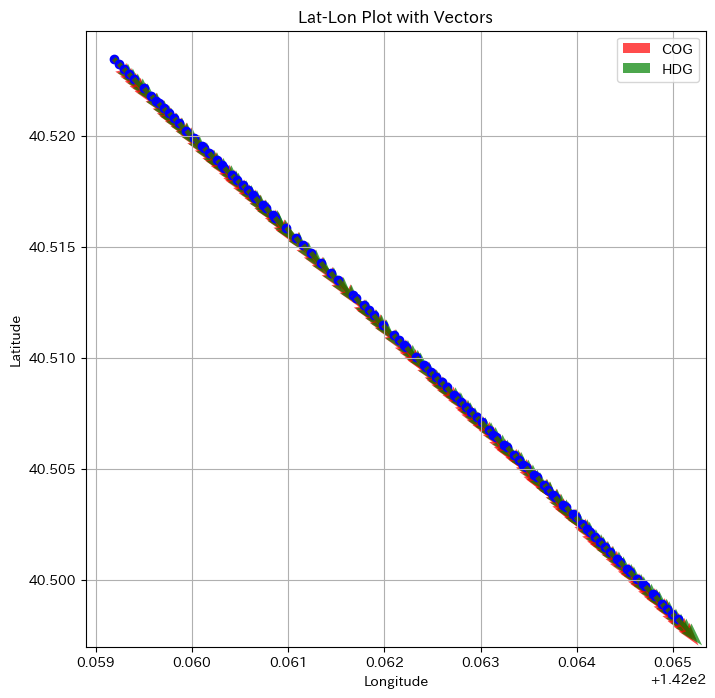

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(8, 8))
plt.title("Lat-Lon Plot with Vectors")

count = 0
for _, row in original_df.iterrows():
    if count>100:
        break

    # 緯度と経度
    lat = float(row["Lat"])
    lon = float(row["Lon"])

    adjust = 20000
    # ベクトルの方向と大きさ
    cog = float(row["COG"])  # 進行方向（角度）
    sog = float(row["SOG"])  # 速度
    dx = (sog * np.sin(np.radians(cog)))/adjust # x方向の変位
    dy = (sog * np.cos(np.radians(cog)))/adjust  # y方向の変位
    # 点とベクトルの描画
    if count==0:
        plt.scatter(lon, lat, color="blue", label="LatLon position")  # 緯度経度に点を打つ
        plt.quiver(lon, lat, dx, dy, angles='xy', scale_units='xy', scale=1, color="red", alpha=0.7, label="COG vec")
    else:
        plt.scatter(lon, lat, color="blue")  # 緯度経度に点を打つ
        plt.quiver(lon, lat, dx, dy, angles='xy', scale_units='xy', scale=1, color="red", alpha=0.7)

    hdg = float(row["HDG"])  # 進行方向（角度）
    dx = (sog * np.sin(np.radians(hdg)))/adjust # x方向の変位
    dy = (sog * np.cos(np.radians(hdg)))/adjust  # y方向の変位
    # 点とベクトルの描画
    if count==0:
        plt.quiver(lon, lat, dx, dy, angles='xy', scale_units='xy', scale=1, color="green", alpha=0.7, label="HDG vec")
    else:
        plt.quiver(lon, lat, dx, dy, angles='xy', scale_units='xy', scale=1, color="green", alpha=0.7)

    count += 1

# ラベル設定
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()